# 데이터 사이언스 특론 6주차 복습 - 통계적 추론

## 1. 통계의 분류 (Remind)

*   **기술 통계 (Descriptive Statistics)**: 현재 가지고 있는 데이터의 특성을 요약 및 설명. 데이터 범위를 넘어서 일반화하기 어려움 → **탐색적 데이터 분석 (EDA)**
*   **추론 통계 (Inferential Statistics)**: 표본 데이터를 바탕으로 모집단에 대한 추론을 가능하게 함 (e.g., t-test). 예측 모델, 기계 학습의 기반이 됨.

### 1.1 통계 지표와 이상치에 대한 민감성

*   **중심 경향성**
    *   **평균 (average)**: 계산이 간편하고 변화가 부드러움 (미적분 기반 수학적 기법에 용이). 단, **이상치에 민감**
    *   **중앙값 (median)**: 이상치에 강건하지만, 전체 데이터 정렬이 필요
*   **산포도**
    *   **분산, 표준편차**: 이상치에 민감
    *   **max, min, 분위값**: 상/하위 25% 등으로 정의하면 이상치에 큰 영향을 받지 않음

### 1.2 공분산과 상관관계 (Remind)

*   두 변수 $(x_i, y_i)$가 함께 변하는 정도를 나타내는 지표
*   **Covariance (공분산)**: 두 변수가 같은/반대 방향으로 변하는지 → $cov(X,Y) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$
*   **Correlation (상관계수)**: 공분산을 각 변수의 표준편차로 나누어 $[-1, 1]$로 정규화 → $corr(X,Y) = \frac{cov(X,Y)}{\sigma_x \sigma_y}$
    *   데이터의 단위를 제거하여 동일한 기준으로 비교 가능

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from math import sqrt

### 1.3 심슨의 역설 (Simpson's Paradox)

*   **혼재변수 (Confounding Variable)** 로 인해 그룹별로 상반되는 통계적 결과가 나타나는 현상
*   상관관계는 **다른 모든 것이 동일할 때** 두 변수의 관계를 나타냄

**예시: 온라인 플랫폼 사용자**

| 지역 | 사용자 수 | 평균 친구 수 |
|------|---------|-----------|
| 미국 서부 | 101 | **8.2** |
| 미국 동부 | 103 | 6.5 |

학위별로 나누면 결과가 역전됨:

| 지역 | 학위 | 사용자 수 | 평균 친구 수 |
|------|------|---------|-----------|
| 미국 서부 | 박사 | 35 | 3.1 |
| 미국 동부 | 박사 | 70 | **3.2** |
| 미국 서부 | 기타 | 66 | 10.9 |
| 미국 동부 | 기타 | 33 | **13.4** |

**예시: 신장 결석 치료법**

전체로 보면 Treatment B가 우수(83% vs 78%)하지만,  
결석 크기별로 나누면 **모든 하위 그룹에서 Treatment A가 우수**:
*   Small stones: A 93% vs B 87%
*   Large stones: A 73% vs B 69%

## 2. 확률

*   **확률**: 사건 공간에서 특정 사건이 발생하는 불확실성을 수치적으로 나타낸 값
*   **종속 사건 (dependent)**: 사건 E의 발생 여부가 사건 F에 대한 정보를 제공
*   **독립 사건 (independent)**: $P(E,F) = P(E \cap F) = P(E) \cdot P(F)$

### 2.1 조건부 확률

$$P(E|F) = \frac{P(E,F)}{P(F)}$$

두 사건이 독립이면 $P(E|F) = P(E)$

**예시: 두 아이의 성별 맞추기**
*   첫째가 딸(G)일 때, 둘 다 딸(B)일 확률: $P(B|G) = \frac{1/4}{1/2} = \frac{1}{2}$
*   딸이 최소 한 명(L)일 때, 둘 다 딸(B)일 확률: $P(B|L) = \frac{1/4}{3/4} = \frac{1}{3}$

In [2]:
# 조건부 확률 예시: 두 아이의 성별
# 전체 표본 공간: {(아들,아들), (아들,딸), (딸,아들), (딸,딸)}
sample_space = [('아들','아들'), ('아들','딸'), ('딸','아들'), ('딸','딸')]

# 사건 B: 둘 다 딸
B = [s for s in sample_space if s[0]=='딸' and s[1]=='딸']

# 사건 G: 첫째가 딸
G = [s for s in sample_space if s[0]=='딸']

# 사건 L: 딸이 최소 한 명
L = [s for s in sample_space if '딸' in s]

P_B_given_G = len([s for s in B if s in G]) / len(G)
P_B_given_L = len([s for s in B if s in L]) / len(L)

print(f"P(B|G) = {P_B_given_G:.4f}  (= 1/2)")
print(f"P(B|L) = {P_B_given_L:.4f}  (= 1/3)")

P(B|G) = 0.5000  (= 1/2)
P(B|L) = 0.3333  (= 1/3)


### 2.2 베이즈 정리 (Bayes's Theorem)

$$P(E|F) = \frac{P(F|E) \cdot P(E)}{P(F)} = \frac{P(F|E) \cdot P(E)}{P(F|E) \cdot P(E) + P(F|\neg E) \cdot P(\neg E)}$$

**예시: 확률의 함정 (희귀 질병 검사)**
*   유병률: 10,000명 중 1명 ($P(D)=0.0001$)
*   검사 정확도: 99% ($P(T|D)=0.99$, $P(T|\neg D)=0.01$)
*   양성 판정 시 실제 질병 확률:

$$P(D|T) = \frac{0.99 \times 0.0001}{0.99 \times 0.0001 + 0.01 \times 0.9999} \approx 0.0098 = 0.98\%$$

→ 양성 판정을 받아도 실제 질병에 걸렸을 확률은 **1%도 안 된다!**

In [3]:
# 베이즈 정리 예시: 희귀 질병 검사
P_D = 0.0001        # 유병률
P_T_given_D = 0.99  # 검사 정확도 (양성|질병)
P_T_given_notD = 0.01  # 위양성률

P_D_given_T = (P_T_given_D * P_D) / (P_T_given_D * P_D + P_T_given_notD * (1 - P_D))
print(f"P(D|T) = {P_D_given_T:.4f} = {P_D_given_T*100:.2f}%")

# 100만명 기준 직관적 이해
n = 1_000_000
sick = int(n * P_D)  # 100명
true_positive = int(sick * P_T_given_D)  # 99명
false_positive = int((n - sick) * P_T_given_notD)  # 9,999명
print(f"\n100만명 중 실제 환자: {sick}명")
print(f"  → 양성 판정: {true_positive}명 (진양성)")
print(f"건강한 사람: {n-sick:,}명")
print(f"  → 양성 판정: {false_positive:,}명 (위양성)")
print(f"총 양성 {true_positive + false_positive:,}명 중 실제 환자: {true_positive}명")

P(D|T) = 0.0098 = 0.98%

100만명 중 실제 환자: 100명
  → 양성 판정: 99명 (진양성)
건강한 사람: 999,900명
  → 양성 판정: 9,999명 (위양성)
총 양성 10,098명 중 실제 환자: 99명


### 2.3 확률 분포 (Distributions)

*   **정규분포 (Normal)**: 가장 기본적인 분포. $f(x|\mu,\sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$
*   **포아송 분포 (Poisson)**: 특정 비율(rate)로 발생하는 사건의 횟수 (e.g., 웹사이트 방문 횟수, 단어 출현 빈도)
*   **지수 분포 (Exponential)**: 사건 사이의 대기시간. $\lambda e^{-\lambda x}$
*   **베타 분포**: 베이즈 추론에서 사용, $x \in [0,1]$
*   **파레토 분포**: 하한선 존재, heavy tail 특성
*   **이항/다항 분포 (Binomial/Multinomial)**: n번 시행 중 특정 사건 발생 횟수

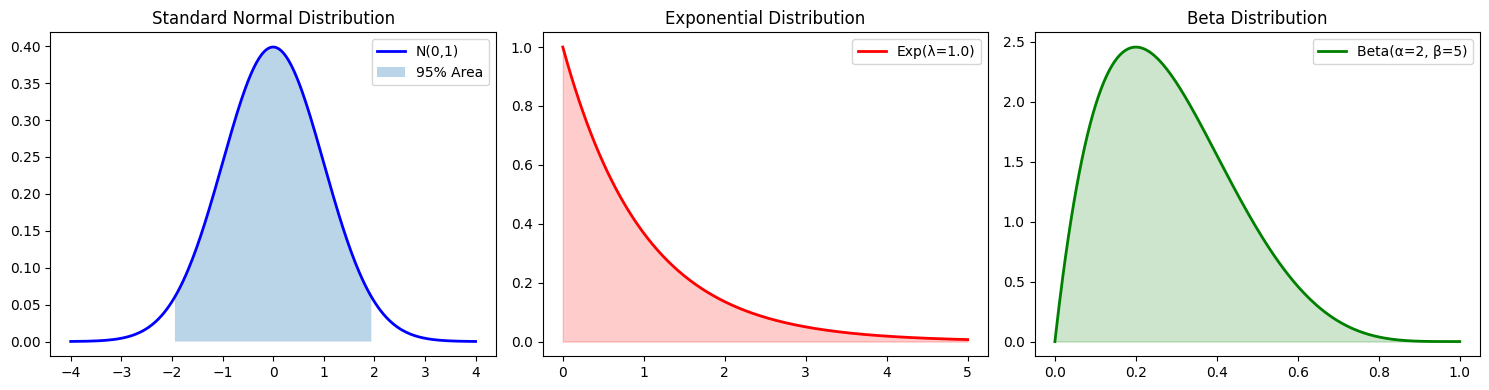

In [4]:
# 주요 확률 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) 정규분포
x = np.linspace(-4, 4, 300)
axes[0].plot(x, stats.norm.pdf(x, 0, 1), 'b-', lw=2, label='N(0,1)')
axes[0].fill_between(x, stats.norm.pdf(x), where=(x>=-1.96)&(x<=1.96), alpha=0.3, label='95% Area')
axes[0].set_title('Standard Normal Distribution')
axes[0].legend()

# 2) 지수분포
x2 = np.linspace(0, 5, 300)
axes[1].plot(x2, stats.expon.pdf(x2, scale=1), 'r-', lw=2, label='Exp(λ=1.0)')
axes[1].fill_between(x2, stats.expon.pdf(x2, scale=1), alpha=0.2, color='red')
axes[1].set_title('Exponential Distribution')
axes[1].legend()

# 3) 베타분포
x3 = np.linspace(0, 1, 300)
axes[2].plot(x3, stats.beta.pdf(x3, 2, 5), 'g-', lw=2, label='Beta(α=2, β=5)')
axes[2].fill_between(x3, stats.beta.pdf(x3, 2, 5), alpha=0.2, color='green')
axes[2].set_title('Beta Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

### 2.4 정규분포와 표준 정규분포

*   평균($\mu$)과 표준편차($\sigma$)만으로 데이터 표현 가능
*   $\mu \pm 2\sigma \approx 95\%$
*   **표준 정규 분포**: $\mu=0$, $\sigma=1$ → $Z = \frac{X - \mu}{\sigma}$

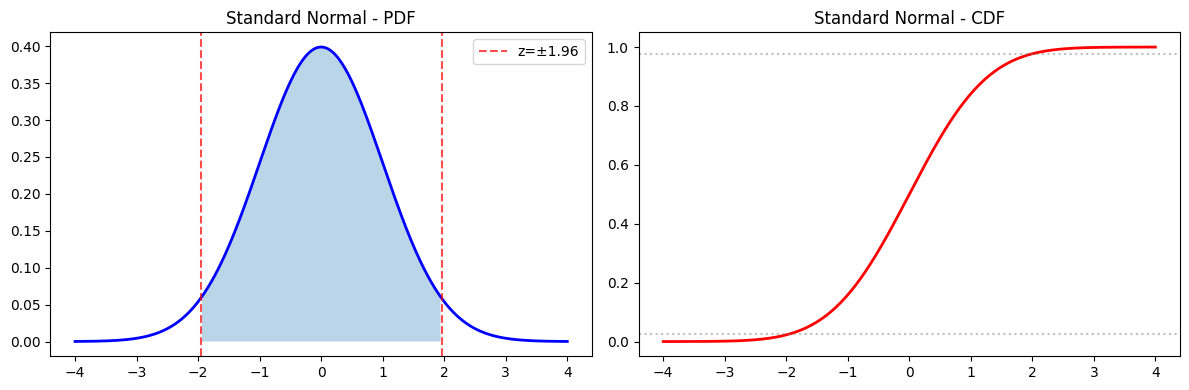

In [5]:
# 정규분포 PDF & CDF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.linspace(-4, 4, 300)

# PDF
axes[0].plot(x, stats.norm.pdf(x), 'b-', lw=2)
axes[0].axvline(-1.96, color='r', ls='--', alpha=0.7, label='z=±1.96')
axes[0].axvline(1.96, color='r', ls='--', alpha=0.7)
axes[0].fill_between(x, stats.norm.pdf(x), where=(x>=-1.96)&(x<=1.96), alpha=0.3)
axes[0].set_title('Standard Normal - PDF')
axes[0].legend()

# CDF
axes[1].plot(x, stats.norm.cdf(x), 'r-', lw=2)
axes[1].axhline(0.025, color='gray', ls=':', alpha=0.5)
axes[1].axhline(0.975, color='gray', ls=':', alpha=0.5)
axes[1].set_title('Standard Normal - CDF')

plt.tight_layout()
plt.show()

### 2.5 중심 극한 정리 (Central Limit Theorem)

*   독립적인 확률변수의 **평균**은 $n$이 충분히 크면 **정규분포**에 근사
*   모집단의 분포가 정규분포가 아니더라도 적용됨
*   t-test 등 통계적 검정 방법들의 이론적 기반
*   통상적으로 최소 **30~50개** 이상의 샘플 필요

> **큰 수의 법칙**: 샘플이 많아질수록 샘플 평균이 모집단 평균에 수렴

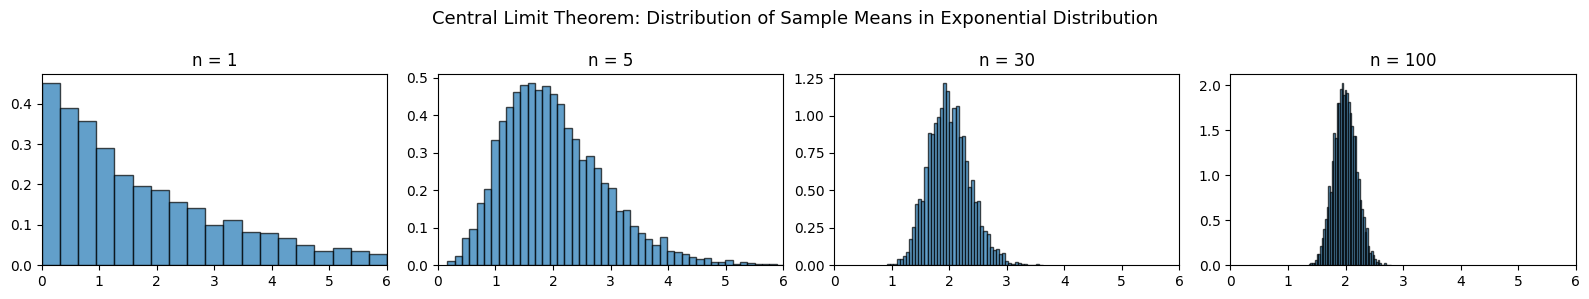

In [18]:
# 중심극한정리 시각화: 지수분포에서 샘플 평균의 분포
np.random.seed(42)
population = np.random.exponential(scale=2, size=100000)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
sample_sizes = [1, 5, 30, 100]

for ax, n in zip(axes, sample_sizes):
    means = [np.mean(np.random.choice(population, n)) for _ in range(5000)]
    ax.hist(means, bins=50, density=True, alpha=0.7, edgecolor='black')
    ax.set_title(f'n = {n}')
    ax.set_xlim(0, 6)

fig.suptitle('Central Limit Theorem: Distribution of Sample Means in Exponential Distribution', fontsize=13)
plt.tight_layout()
plt.show()

### 2.6 분포의 보정

실제 데이터가 정규분포를 따르지 않을 때:
*   $X$가 **log-normal** → $Y = \ln(X)$가 정규분포
*   $X$가 **포아송 분포** → $\sqrt{X}$가 표준정규분포로 근사 가능
*   히스토그램을 그려서 분포를 먼저 확인하는 것이 중요

## 3. 가설과 추론

### 3.1 모집단, 표본, 통계적 추론

*   **모집단 (population)**: 분석하고자 하는 대상 전체
*   **표본 (sample)**: 실제로 수집한 데이터 (모집단의 부분집합)
*   **통계적 추론 (Statistical Inference)**: 표본 데이터를 분석하여 모집단의 특성을 파악하는 과정

### 3.2 샘플 편향 (Sampling Bias)

*   표본 추출 방법의 문제로 표본이 모집단을 대표하지 못할 때 발생
*   **Random sampling**이 편향 방지의 핵심
*   현실적으로 완벽한 random sample을 얻기는 매우 어려움

**여론조사에서의 보정 예시 (한국 갤럽)**:
1.  **RDD (Random Digit Dialing)**: 무작위 번호 생성으로 표본의 randomness 극대화
2.  **할당 추출 (Quota Sampling)**: 성별/연령/지역별 인구 비례에 맞춰 목표 표본 수 할당
3.  **사후 가중 (Post-weighting)**: 수집된 표본 비율과 모집단 비율의 차이를 가중치로 보정

### 3.3 편향 (Bias)의 종류

*   **Sampling bias**: 표본 추출 문제
*   **Question wording**: 질문의 방식/단어 선택이 응답에 영향
*   **Context / Conditional probability**: 정보 제시 상황에 의한 판단 왜곡
*   **부정확한 응답**: Self-confidence bias, 플라시보 효과 등

### 3.4 Experiment vs. Observational Study

*   **실험 (Experiment)**: 연구자가 Explanatory variables를 능동적으로 제어/통제
*   **관찰 연구 (Observational Study)**: 변수를 인위적으로 제어하지 않고 자연스러운 데이터를 관찰
    *   관찰 연구는 **인과관계(Causation)** 를 확립하는 데 거의 사용될 수 없음

### 3.5 통계적 가설검정 (Statistical Hypothesis Testing)

*   **가설**: 데이터 통계치에 대한 이야기로 변환될 수 있는 주장
*   **귀무가설 ($H_0$, Null Hypothesis)**: 기본 입장. 보통 "효과/차이가 없다"
*   **대립가설 ($H_1$, Alternative Hypothesis)**: 데이터를 통해 입증하고자 하는 주장
*   귀무가설을 **기각**하는지, **기각하지 못하는지**로 판단 (기각 실패 ≠ 귀무가설이 참)

**법정 비유:**
*   $H_0$: 피고인은 무죄 (무죄 추정의 원칙)
*   $H_1$: 피고인은 유죄
*   유죄 판결 = 귀무가설 기각 (강력한 증거)
*   무죄 판결 = 기각 실패 (유죄 증거 불충분, 결백 확정이 아님)

### 3.6 가설검정의 일반적 절차

1.  **가설 설정** (State Hypotheses)
2.  **검정 통계량 계산**
3.  **귀무가설 하의 분포 생성**: $H_0$이 참일 때 검정 통계량이 따르는 이론적 분포 확인
4.  **극단성 측정**: 관측된 통계량이 얼마나 발생하기 힘든 값인지 측정 → **p-value**

### 3.7 통계적 의사결정과 p-value

*   **p-value가 작은 경우** → $H_0$ **기각** → 통계적으로 유의미
*   **p-value가 크거나 같은 경우** → $H_0$을 기각하지 못함 → 결정적이지 않음 (Inconclusive)

### 3.8 가설검정의 오류

| | $H_0$ 유지 (Retain) | $H_0$ 기각 (Reject) |
|---|---|---|
| **$H_0$ 참** | 옳은 결정 ($1-\alpha$) | **제1종 오류** ($\alpha$, False Positive) |
| **$H_0$ 거짓** | **제2종 오류** ($\beta$, False Negative) | 옳은 결정 ($1-\beta$, Power) |

*   **유의수준 ($\alpha$)**: 제1종 오류 허용 수준 (보통 5% 또는 1%)
*   **검정력 (Power, $1-\beta$)**: 대립가설이 참일 때 올바르게 기각할 확률

### 3.9 가설검정 예시 - 동전 던지기

*   $H_0$: $p = 0.5$ (공평한 동전)
*   $H_1$: $p \neq 0.5$
*   동전을 $n$번 던져서 앞면 횟수 $X = \sum_{i=1}^{n} X_i$ (이항분포 → 정규분포 근사)
    *   $E[X] = np$, $\sigma_X = \sqrt{np(1-p)}$

In [7]:
# 동전 던지기 가설검정 예시
n = 1000
p_null = 0.50
mu = n * p_null          # 500
sigma = sqrt(n * p_null * (1 - p_null))  # ≈ 15.8
alpha = 0.05

# 양측 검정 기각 경계
lower_limit = stats.norm.ppf(alpha / 2, loc=mu, scale=sigma)
upper_limit = stats.norm.ppf(1 - alpha / 2, loc=mu, scale=sigma)

print(f"E[X] = {mu}")
print(f"σ_X = {sigma:.2f}")
print(f"유의수준 {alpha*100:.0f}% 기준 채택 범위: [{lower_limit:.1f}, {upper_limit:.1f}]")

E[X] = 500.0
σ_X = 15.81
유의수준 5% 기준 채택 범위: [469.0, 531.0]


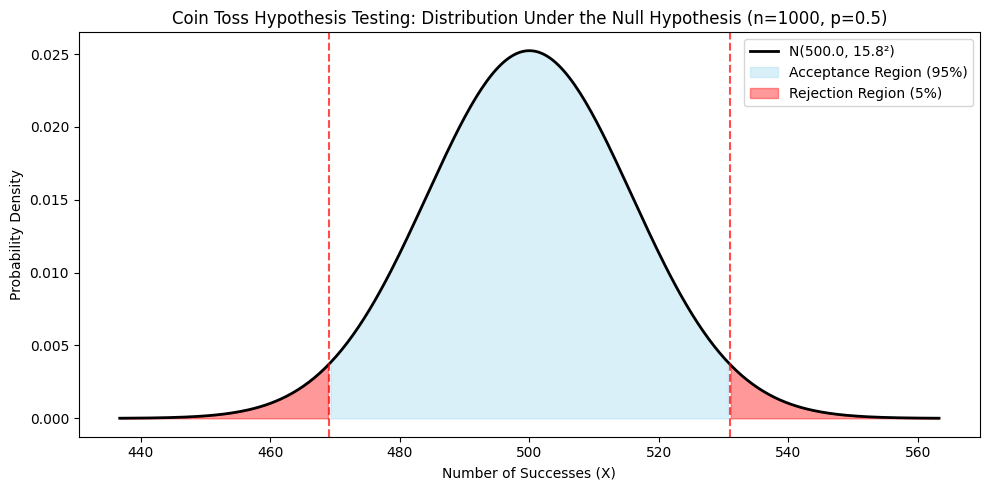

In [11]:
# 동전 던지기: 귀무가설 분포 & 기각 영역 시각화
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10, 5))
plt.plot(x, y, 'k-', lw=2, label=f'N({mu}, {sigma:.1f}²)')

# 채택 영역
plt.fill_between(x, y, where=(x >= lower_limit) & (x <= upper_limit),
                 alpha=0.3, color='skyblue', label='Acceptance Region (95%)')
# 기각 영역
plt.fill_between(x, y, where=(x < lower_limit),
                 alpha=0.4, color='red', label='Rejection Region (5%)')
plt.fill_between(x, y, where=(x > upper_limit),
                 alpha=0.4, color='red')

plt.axvline(lower_limit, color='r', ls='--', alpha=0.7)
plt.axvline(upper_limit, color='r', ls='--', alpha=0.7)
plt.title('Coin Toss Hypothesis Testing: Distribution Under the Null Hypothesis (n=1000, p=0.5)')
plt.xlabel('Number of Successes (X)')
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()

### 3.10 검정력 (Power) 계산

*   대립가설 하에서 $p = 0.55$로 가정
*   제2종 오류($\beta$): 대립가설이 참인데 귀무가설의 채택역에 떨어질 확률
*   검정력 = $1 - \beta$

In [9]:
# 검정력 계산: p_alt = 0.55
p_alt = 0.55
mu_a = n * p_alt                          # 550
sigma_a = sqrt(n * p_alt * (1 - p_alt))   # ≈ 15.73

# 제2종 오류: 대립가설 분포에서 귀무가설 채택역에 떨어질 확률
type_2_error = stats.norm.cdf(upper_limit, loc=mu_a, scale=sigma_a) -                stats.norm.cdf(lower_limit, loc=mu_a, scale=sigma_a)
power = 1 - type_2_error

print(f"대립가설 (p={p_alt})의 평균: {mu_a}, 표준편차: {sigma_a:.2f}")
print(f"제2종 오류 (Beta): {type_2_error:.4f}")
print(f"검정력 (Power = 1 - Beta): {power:.4f}")

대립가설 (p=0.55)의 평균: 550.0, 표준편차: 15.73
제2종 오류 (Beta): 0.1135
검정력 (Power = 1 - Beta): 0.8865


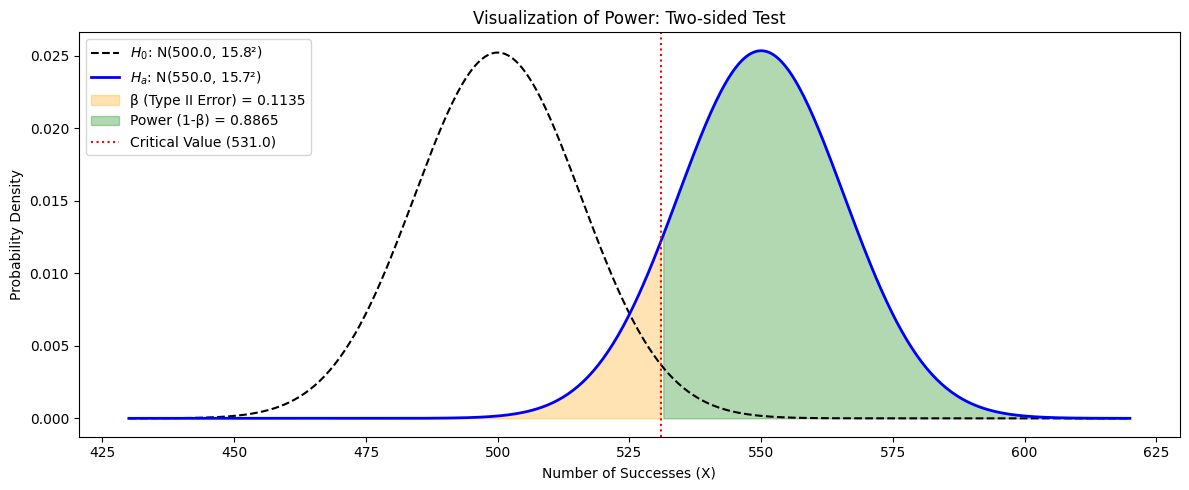

In [13]:
# 검정력 시각화: 귀무가설 vs 대립가설 분포
x = np.linspace(430, 620, 400)

fig, ax = plt.subplots(figsize=(12, 5))

# 귀무가설 분포
y0 = stats.norm.pdf(x, loc=mu, scale=sigma)
ax.plot(x, y0, 'k--', lw=1.5, label=f'$H_0$: N({mu}, {sigma:.1f}²)')

# 대립가설 분포
y1 = stats.norm.pdf(x, loc=mu_a, scale=sigma_a)
ax.plot(x, y1, 'b-', lw=2, label=f'$H_a$: N({mu_a}, {sigma_a:.1f}²)')

# β (Type II Error) 영역
ax.fill_between(x, y1, where=(x >= lower_limit) & (x <= upper_limit),
                alpha=0.3, color='orange', label=f'β (Type II Error) = {type_2_error:.4f}')

# Power 영역
ax.fill_between(x, y1, where=(x > upper_limit),
                alpha=0.3, color='green', label=f'Power (1-β) = {power:.4f}')

ax.axvline(upper_limit, color='r', ls=':', lw=1.5, label=f'Critical Value ({upper_limit:.1f})')
ax.set_xlabel('Number of Successes (X)')
ax.set_ylabel('Probability Density')
ax.set_title('Visualization of Power: Two-sided Test')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
# 단측 검정 시 검정력 비교
hi_one_sided = stats.norm.ppf(0.95, loc=mu, scale=sigma)
beta_one = stats.norm.cdf(hi_one_sided, loc=mu_a, scale=sigma_a)
power_one = 1 - beta_one

print(f"양측 검정 기각 기준 (상한): {upper_limit:.1f}")
print(f"단측 검정 기각 기준 (상한): {hi_one_sided:.1f}")
print(f"\n양측 검정 검정력: {power:.4f}")
print(f"단측 검정 검정력: {power_one:.4f}")
print(f"\n→ 편향 방향을 알고 있다면 단측 검정이 더 높은 검정력을 가짐")

양측 검정 기각 기준 (상한): 531.0
단측 검정 기각 기준 (상한): 526.0

양측 검정 검정력: 0.8865
단측 검정 검정력: 0.9364

→ 편향 방향을 알고 있다면 단측 검정이 더 높은 검정력을 가짐


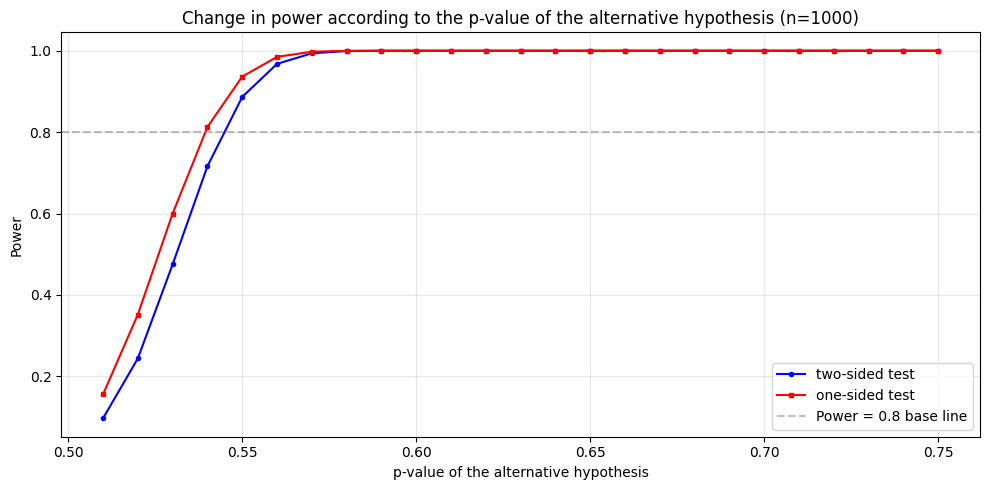

In [17]:
# p_alt 값에 따른 검정력 변화
p_alts = np.arange(0.51, 0.76, 0.01)
powers_two = []
powers_one = []

for p in p_alts:
    mu_a_i = n * p
    sigma_a_i = sqrt(n * p * (1 - p))
    beta_two = stats.norm.cdf(upper_limit, loc=mu_a_i, scale=sigma_a_i) -                stats.norm.cdf(lower_limit, loc=mu_a_i, scale=sigma_a_i)
    beta_one_i = stats.norm.cdf(hi_one_sided, loc=mu_a_i, scale=sigma_a_i)
    powers_two.append(1 - beta_two)
    powers_one.append(1 - beta_one_i)

plt.figure(figsize=(10, 5))
plt.plot(p_alts, powers_two, 'b-o', markersize=3, label='two-sided test')
plt.plot(p_alts, powers_one, 'r-s', markersize=3, label='one-sided test')
plt.axhline(0.8, color='gray', ls='--', alpha=0.5, label='Power = 0.8 base line')
plt.xlabel('p-value of the alternative hypothesis')
plt.ylabel('Power')
plt.title('Change in power according to the p-value of the alternative hypothesis (n=1000)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.11 확률의 활용 방향 정리

| 구분 | 통계적 추론 (Data Science) | 불규칙 과정 (Comm. & Signal) |
|------|--------------------------|---------------------------|
| **목표** | 표본으로 모집단 특성 파악 | 시간에 따른 확률적 시스템 모델링 |
| **주요 도구** | 가설검정, 신뢰구간, 파라미터 최적화 | 포아송 프로세스, 큐잉 이론 |
| **관점** | 데이터 = 특정 시점의 snapshot | 데이터 = 연속적인 flow |
| **핵심 질문** | 이 결과가 우연인가, 모집단의 특징인가? | 지연 시간은 허용 가능한가, 병목인가? |